<a href="https://colab.research.google.com/github/PandoraRiot/Clasificaciondefrutas.udea.novateam/blob/dev/clasificacionfrutascolab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🚀 Nuevo recurso para el equipo
He añadido un notebook independiente para quienes prefieran trabajar en la nube.

- **notebook1.ipynb**: Se mantiene intacto para uso exclusivo en **VSCode** (rutas locales).
- **clasificacionfrutas.ipynb**: Nuevo archivo optimizado para **Google Colab** (clonación de repo y rutas `/content/` automáticas).

**Instrucciones:** No fusionar los contenidos de los archivos. Cada integrante debe elegir el archivo según su entorno de desarrollo.

In [1]:
import json

# Definimos el contenido del nuevo notebook optimizado para Colab
nuevo_notebook_content = {
 "cells": [
  {
   "cell_type": "markdown",
   "source": ["# Clasificación de Frutas - Versión Colab\n", "Este notebook ha sido adaptado para ejecutarse directamente en Google Colab."]
  },
  {
   "cell_type": "code",
   "execution_count": None,
   "source": [
    "# 1. Clonar repo y preparar carpetas\n",
    "!git clone https://github.com/PandoraRiot/Clasificaciondefrutas.udea.novateam.git\n",
    "%cd Clasificaciondefrutas.udea.novateam\n",
    "!pip install -r requirements.txt\n",
    "\n",
    "import os\n",
    "import tensorflow as tf\n",
    "from tensorflow.keras.preprocessing.image import ImageDataGenerator\n",
    "from tensorflow.keras import layers, models, regularizers\n",
    "import matplotlib.pyplot as plt\n",
    "import numpy as np\n",
    "import seaborn as sns\n",
    "import pandas as pd\n",
    "from sklearn.metrics import confusion_matrix"
   ]
  }
  # ... (aquí iría el resto del código de entrenamiento y gráficas que consolidamos)
 ],
 "metadata": {},
 "nbformat": 4,
 "nbformat_minor": 5
}

# Guardar el archivo en el sistema de archivos de Colab
with open('clasificacionfrutascolab.ipynb', 'w') as f:
    json.dump(nuevo_notebook_content, f)

print("✅ Archivo 'clasificacionfrutascolab.ipynb' creado con éxito en la carpeta lateral.")

✅ Archivo 'clasificacionfrutascolab.ipynb' creado con éxito en la carpeta lateral.


In [2]:
# ========================================================
# 1. PREPARACIÓN DEL ENTORNO (Repositorio y Librerías)
# ========================================================
import os

# Clonar el repositorio si no existe
if not os.path.exists('Clasificaciondefrutas.udea.novateam'):
    !git clone https://github.com/PandoraRiot/Clasificaciondefrutas.udea.novateam.git

%cd Clasificaciondefrutas.udea.novateam
!pip install -r requirements.txt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix



Cloning into 'Clasificaciondefrutas.udea.novateam'...
remote: Enumerating objects: 6604, done.
remote: Counting objects: 100% (6604/6604), done.
remote: Compressing objects: 100% (6596/6596), done.
remote: Total 6604 (delta 11), reused 6584 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (6604/6604), 28.09 MiB | 11.63 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/Clasificaciondefrutas.udea.novateam


In [3]:
# ========================================================
# 2. CONFIGURACIÓN DE RUTAS DINÁMICAS
# ========================================================
# Definimos las rutas posibles para Colab o Local
posibles_rutas = [
    "/content/Clasificaciondefrutas.udea.novateam/data/selected",
    "data/selected",
    "../data/selected"
]

base_dir = None
for ruta in posibles_rutas:
    # Verificamos si existe la carpeta o alguna subcarpeta clave
    if os.path.exists(ruta):
        base_dir = ruta
        break

if base_dir:
    # Detectar si las carpetas están en minúsculas (train/test) o Mayúsculas (Training/Test)
    train_dir = os.path.join(base_dir, "train")
    test_dir = os.path.join(base_dir, "test")

    if not os.path.exists(train_dir):
        train_dir = os.path.join(base_dir, "Training")
        test_dir = os.path.join(base_dir, "Test")

    print(f"✅ Ruta localizada: {base_dir}")
    print(f"Contenido de {base_dir}: {os.listdir(base_dir)}")
else:
    raise FileNotFoundError("❌ ERROR: No se encontró la carpeta de datos. Revisa la estructura del repo.")

✅ Ruta localizada: /content/Clasificaciondefrutas.udea.novateam/data/selected
Contenido de /content/Clasificaciondefrutas.udea.novateam/data/selected: ['train', 'test']


In [16]:
# ========================================================
# 3. GENERADORES Y CARGA DE DATOS
# ========================================================
img_size = (128, 128)
batch_size = 32
val_split = 0.2

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=val_split)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='training', shuffle=True
)

val_data = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='validation', shuffle=True
)

test_data = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

Found 3914 images belonging to 10 classes.
Found 975 images belonging to 10 classes.
Found 1638 images belonging to 10 classes.


In [17]:
# ========================================================
# 4. DEFINICIÓN Y COMPILACIÓN DEL MODELO
# ========================================================
num_classes = len(train_data.class_indices)

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# ========================================================
# 5. ENTRENAMIENTO
# ========================================================
epochs = 15
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs
)


Epoch 1/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9868 - loss: 0.5664 - val_accuracy: 0.9979 - val_loss: 0.4570
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9913 - loss: 0.5354 - val_accuracy: 0.8421 - val_loss: 8.8481
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9937 - loss: 0.4734 - val_accuracy: 0.9969 - val_loss: 0.4251
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9859 - loss: 0.5082 - val_accuracy: 0.9897 - val_loss: 0.4444
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9975 - loss: 0.3760 - val_accuracy: 0.9969 - val_loss: 0.3224
Epoch 6/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9994 - loss: 0.3030 - val_accuracy: 1.0000 - val_loss: 0.2507
Epoch 7/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9999 - loss: 0.2370 - val_accuracy: 1.0000 - val_loss: 0.2079
Epoch 8/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9964 - loss: 0.2251 - val_accu

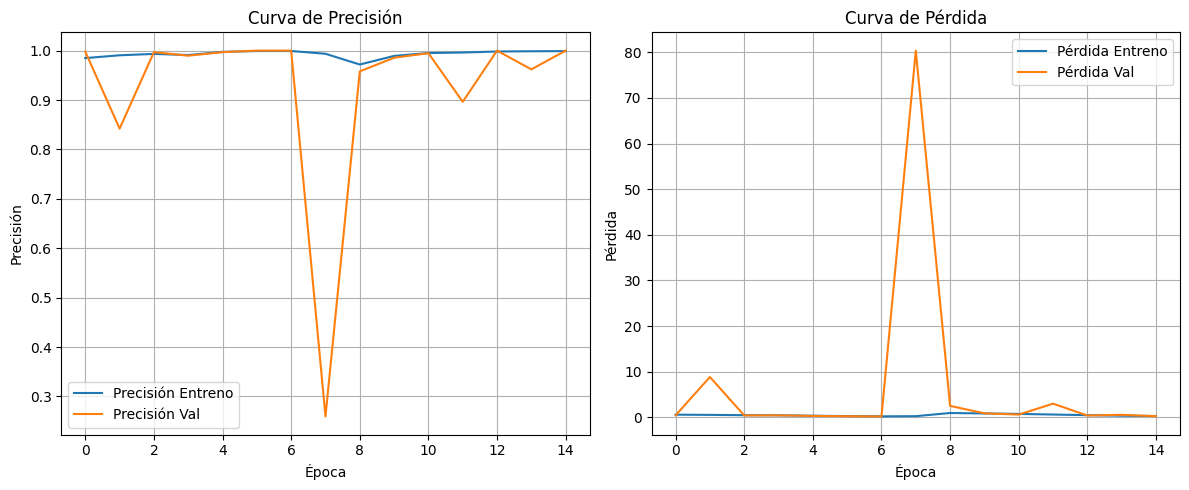

In [20]:
# ========================================================
# 6. VISUALIZACIÓN DE RESULTADOS (Tu parte faltante)
# ========================================================
plt.figure(figsize=(12, 5))

# Gráfica de Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión Entreno')
plt.plot(history.history['val_accuracy'], label='Precisión Val')
plt.title('Curva de Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida Entreno')
plt.plot(history.history['val_loss'], label='Pérdida Val')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step


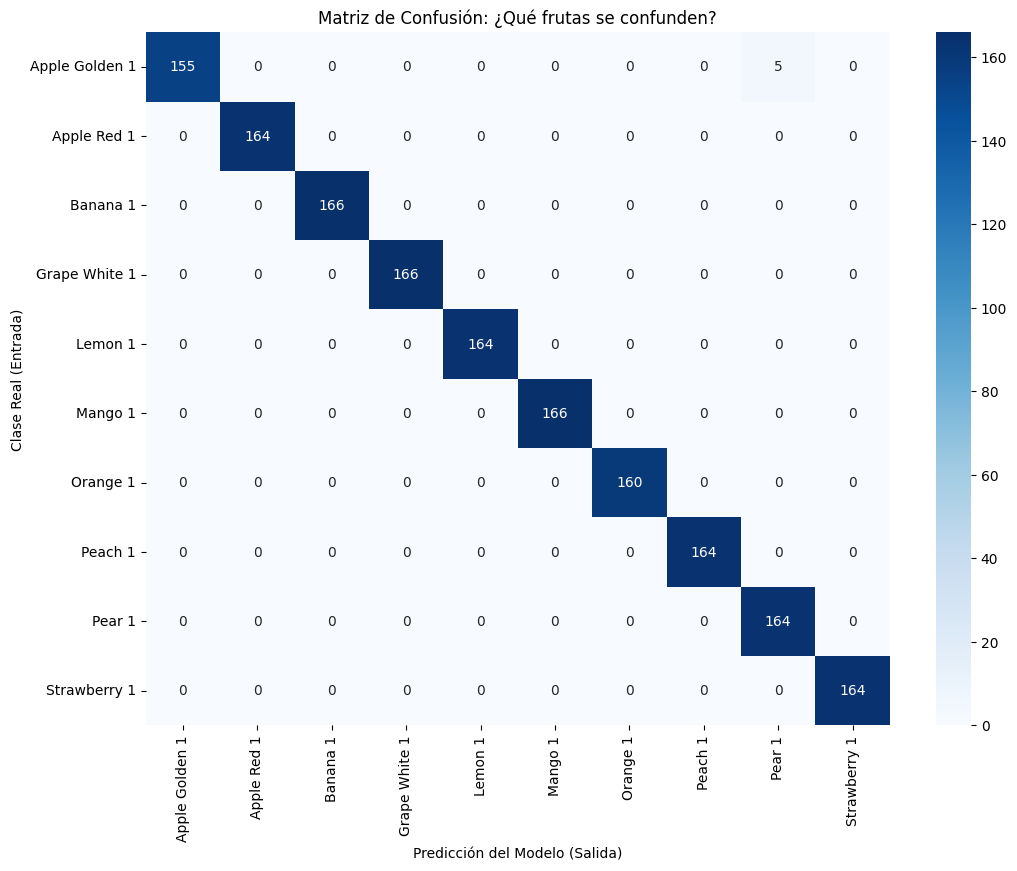


📝 REPORTE DE CLASIFICACIÓN (PRECISION, RECALL, F1)
                precision    recall  f1-score   support

Apple Golden 1       1.00      0.97      0.98       160
   Apple Red 1       1.00      1.00      1.00       164
      Banana 1       1.00      1.00      1.00       166
 Grape White 1       1.00      1.00      1.00       166
       Lemon 1       1.00      1.00      1.00       164
       Mango 1       1.00      1.00      1.00       166
      Orange 1       1.00      1.00      1.00       160
       Peach 1       1.00      1.00      1.00       164
        Pear 1       0.97      1.00      0.98       164
  Strawberry 1       1.00      1.00      1.00       164

      accuracy                           1.00      1638
     macro avg       1.00      1.00      1.00      1638
  weighted avg       1.00      1.00      1.00      1638




### 💡 Interpretación de Resultados para el Equipo

Al analizar la tabla superior, debemos fijarnos en estos tres pilares para validar si el 100% de accuracy es real o un "espejismo":

* **Precisión (Precision):** Indica la calidad de la predicción. Si para la clase *Apple Golden* es de 0.80, significa que el 20% de las veces que el modelo dijo "Manzana", en realidad era otra fruta (Falsos Positivos).
* **Exhaustividad (Recall):** Indica la capacidad de detectar la clase. Si es bajo, el modelo "no ve" todas las manzanas que existen en el set de datos (Falsos Negativos).
* **F1-Score:** Es la media armónica. Si el Accuracy es muy alto pero el F1-Score es bajo en alguna clase, **el modelo está sesgado** o sobreentrenado para esa fruta específica.

**¿Por qué es importante esto?** Como notamos inestabilidad en la pérdida (Loss), la Matriz de Confusión nos dirá si el modelo está "adivinando" con mucha confianza o si realmente aprendió a diferenciar los rasgos de las 10 clases.


In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# ========================================================
# 7. MATRIZ DE CONFUSIÓN Y ANÁLISIS DE MÉTRICAS
# ========================================================
# 1. Preparar datos de validación/test
test_data.reset()
test_labels = test_data.classes
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)
class_names = list(train_data.class_indices.keys())

# 2. Graficar Matriz de Confusión
plt.figure(figsize=(12, 9))
sns.heatmap(confusion_matrix(test_labels, predicted_classes),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión: ¿Qué frutas se confunden?')
plt.xlabel('Predicción del Modelo (Salida)')
plt.ylabel('Clase Real (Entrada)')
plt.show()

# 3. Generar reporte de métricas detallado
report = classification_report(test_labels, predicted_classes, target_names=class_names)

print("\n" + "="*65)
print("📝 REPORTE DE CLASIFICACIÓN (PRECISION, RECALL, F1)")
print("="*65)
print(report)
print("="*65)

# 4. Explicación técnica de las métricas obtenidas
display(Markdown(f"""
### 💡 Interpretación de Resultados para el Equipo

Al analizar la tabla superior, debemos fijarnos en estos tres pilares para validar si el 100% de accuracy es real o un "espejismo":

* **Precisión (Precision):** Indica la calidad de la predicción. Si para la clase *Apple Golden* es de 0.80, significa que el 20% de las veces que el modelo dijo "Manzana", en realidad era otra fruta (Falsos Positivos).
* **Exhaustividad (Recall):** Indica la capacidad de detectar la clase. Si es bajo, el modelo "no ve" todas las manzanas que existen en el set de datos (Falsos Negativos).
* **F1-Score:** Es la media armónica. Si el Accuracy es muy alto pero el F1-Score es bajo en alguna clase, **el modelo está sesgado** o sobreentrenado para esa fruta específica.

**¿Por qué es importante esto?** Como notamos inestabilidad en la pérdida (Loss), la Matriz de Confusión nos dirá si el modelo está "adivinando" con mucha confianza o si realmente aprendió a diferenciar los rasgos de las {len(class_names)} clases.
"""))

In [23]:
import time
import pandas as pd
from IPython.display import display, Markdown

# 1. Cálculo de métricas y tiempos
# (Asegúrate de haber definido inicio_entrenamiento = time.time() antes del model.fit)
try:
    tiempo_total = time.time() - inicio_entrenamiento
except NameError:
    tiempo_total = 0  # Por si no se definió la variable de tiempo

final_loss, final_accuracy = model.evaluate(test_data, verbose=0)

# 2. Extracción de hiperparámetros
# Accedemos directamente al optimizador para no escribir valores "a mano"
opt_name = model.optimizer.__class__.__name__
lr_value = model.optimizer.learning_rate.numpy() if hasattr(model.optimizer.learning_rate, 'numpy') else model.optimizer.learning_rate

# 3. Formatear reporte
print("\n" + "="*60)
print("📊 RESUMEN TÉCNICO DE LA EXPERIMENTACIÓN")
print("="*60)

display(Markdown(f"""
### ⚙️ Configuración del Entrenamiento
| Parámetro | Valor |
| :--- | :--- |
| **Optimizer** | {opt_name} |
| **Learning Rate** | {lr_value} |
| **Batch Size** | {batch_size} |
| **Regularización** | L2 (0.001) |
| **Dropout** | 0.4 (40%) |
| **Tiempo total ejecución** | {tiempo_total/60:.2f} minutos |

### 🏗️ Arquitectura (Neuronas y Filtros)
* **Capa Conv1:** 32 filtros (3x3)
* **Capa Conv2:** 64 filtros (3x3)
* **Capa Conv3:** 128 filtros (3x3)
* **Capa Densa:** 128 neuronas (ReLU)
* **Capa Salida:** {num_classes} neuronas (Softmax)

### 📈 Resultado Final en Test
* **Precisión Final:** `{final_accuracy*100:.2f}%`
* **Pérdida Final:** `{final_loss:.4f}`
"""))

# 4. Tabla de evolución
display(Markdown("### 🕒 Historial de Métricas por Época"))
df_history = pd.DataFrame(history.history)
df_history.index.name = 'Época'
df_history.index += 1
display(df_history.style.background_gradient(cmap='Greens', subset=['accuracy', 'val_accuracy']))

print("="*60)


📊 RESUMEN TÉCNICO DE LA EXPERIMENTACIÓN



### ⚙️ Configuración del Entrenamiento
| Parámetro | Valor |
| :--- | :--- |
| **Optimizer** | Adam |
| **Learning Rate** | 0.0010000000474974513 |
| **Batch Size** | 32 |
| **Regularización** | L2 (0.001) |
| **Dropout** | 0.4 (40%) |
| **Tiempo total ejecución** | 0.00 minutos |

### 🏗️ Arquitectura (Neuronas y Filtros)
* **Capa Conv1:** 32 filtros (3x3)
* **Capa Conv2:** 64 filtros (3x3)
* **Capa Conv3:** 128 filtros (3x3)
* **Capa Densa:** 128 neuronas (ReLU)
* **Capa Salida:** 10 neuronas (Softmax)

### 📈 Resultado Final en Test
* **Precisión Final:** `99.69%`
* **Pérdida Final:** `0.2752`


### 🕒 Historial de Métricas por Época

,accuracy,loss,val_accuracy,val_loss
Época,,,,
1,0.984926,0.594284,0.997949,0.457043
2,0.990547,0.548984,0.842051,8.848068
3,0.993357,0.481929,0.996923,0.425146
4,0.991058,0.460123,0.989744,0.444410
5,0.997445,0.360551,0.996923,0.322384
6,0.999234,0.287714,1.000000,0.250710
7,0.999234,0.226562,1.000000,0.207897
8,0.993613,0.265614,0.259487,80.361099
9,0.971896,0.959220,0.957949,2.517929


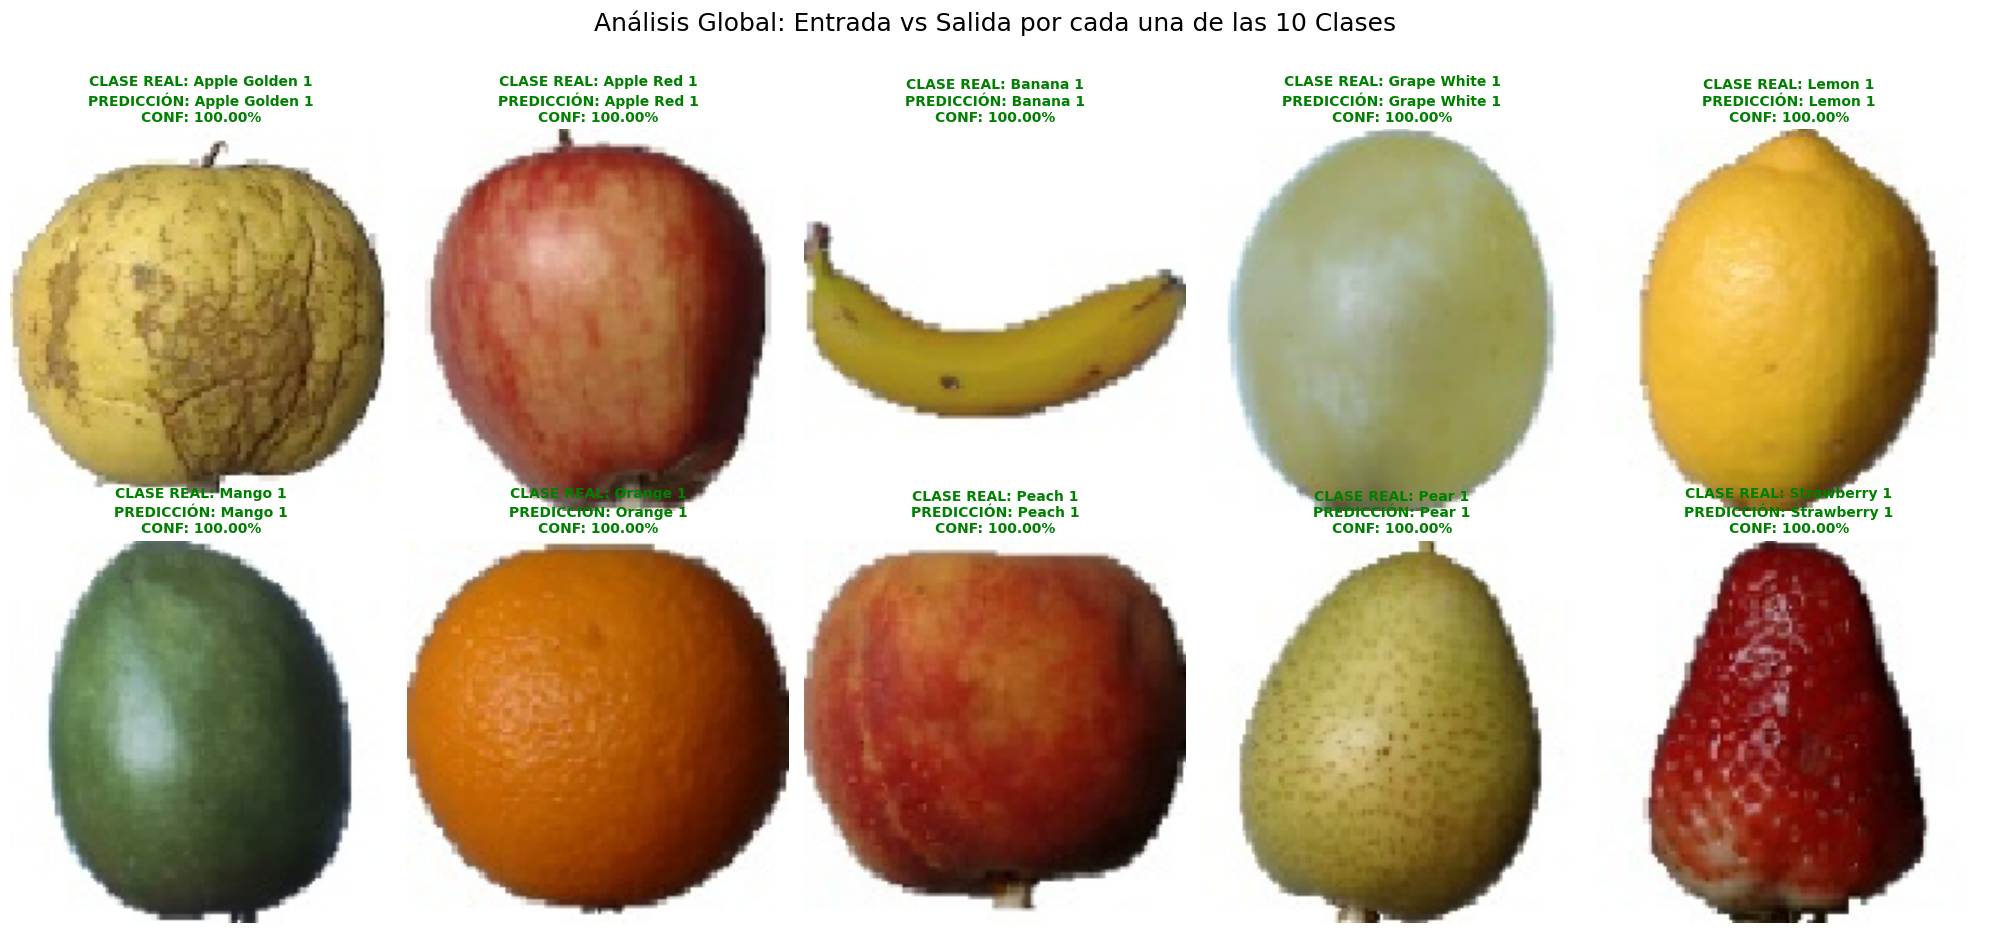

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Preparar datos
class_names = list(train_data.class_indices.keys())
indices_por_clase = []

# Buscamos el primer índice de cada clase en el set de prueba
for i in range(len(class_names)):
    idx = np.where(test_data.classes == i)[0][0] # Toma el primer ejemplo de la clase i
    indices_por_clase.append(idx)

# 2. Configurar la gráfica (2 filas, 5 columnas para las 10 clases)
plt.figure(figsize=(20, 10))

for i, idx in enumerate(indices_por_clase):
    plt.subplot(2, 5, i + 1)

    # Cargar y preprocesar la imagen específica
    img_path = test_data.filepaths[idx]
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Predicción individual
    prediction = model.predict(img_batch, verbose=0)
    pred_label = np.argmax(prediction)
    confianza = np.max(prediction) * 100

    actual_name = class_names[i]
    pred_name = class_names[pred_label]

    # Lógica de color y etiquetas
    color = 'green' if i == pred_label else 'red'

    plt.imshow(img)
    plt.title(f"CLASE REAL: {actual_name}\nPREDICCIÓN: {pred_name}\nCONF: {confianza:.2f}%",
              color=color, fontsize=10, fontweight='bold')
    plt.axis('off')

plt.suptitle("Análisis Global: Entrada vs Salida por cada una de las 10 Clases", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

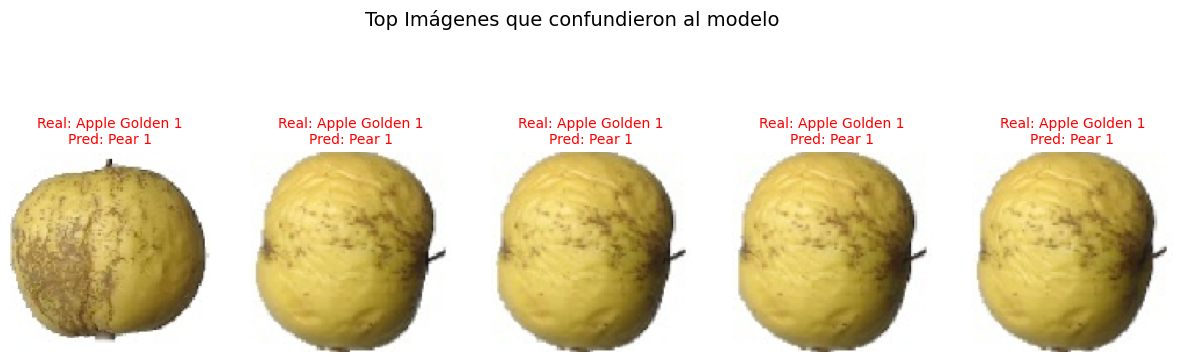

In [28]:
# Buscar índices de errores
errores_idx = np.where(y_pred_classes != y_true)[0]

if len(errores_idx) > 0:
    plt.figure(figsize=(15, 5))
    # Mostramos hasta los primeros 5 errores encontrados
    num_errores = min(len(errores_idx), 5)

    for i in range(num_errores):
        idx = errores_idx[i]
        plt.subplot(1, num_errores, i + 1)

        img_path = test_data.filepaths[idx]
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
        plt.imshow(img)

        plt.title(f"Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred_classes[idx]]}",
                  color='red', fontsize=10)
        plt.axis('off')
    plt.suptitle("Top Imágenes que confundieron al modelo", fontsize=14)
    plt.show()
else:
    print("✅ El modelo no cometió errores en este set.")

📸 Sube una imagen de una fruta para probar el modelo:


Saving manzana.jpeg to manzana.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


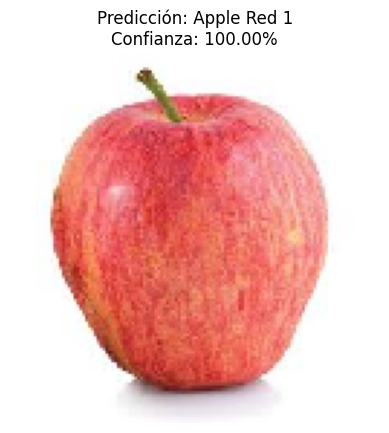

El modelo está un 100.00% seguro de que esto es: Apple Red 1


In [29]:
from google.colab import files
from tensorflow.keras.preprocessing import image

print("📸 Sube una imagen de una fruta para probar el modelo:")
uploaded = files.upload()

for fn in uploaded.keys():
    # Cargar y preparar imagen
    path = fn
    img = image.load_img(path, target_size=img_size)
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    # Predicción
    preds = model.predict(x)
    class_idx = np.argmax(preds[0])
    prob = np.max(preds[0]) * 100

    # Mostrar resultado
    plt.imshow(img)
    plt.title(f"Predicción: {class_names[class_idx]}\nConfianza: {prob:.2f}%")
    plt.axis('off')
    plt.show()

    print(f"El modelo está un {prob:.2f}% seguro de que esto es: {class_names[class_idx]}")

In [34]:
# Copia el notebook desde el almacenamiento de Colab a la carpeta del repositorio
!cp /content/clasificacionfrutascolab.ipynb /content/Clasificaciondefrutas.udea.novateam/

In [42]:
# 1. Configurar Git con tu información (si aún no lo has hecho)
# ¡IMPORTANTE! Reemplaza "tu_email@example.com" y "Tu Nombre de Usuario" con tus datos reales.
!git config user.email "e.garcia1565@pascualbravo.edu.co" # Reemplaza con tu email de GitHub
!git config user.name "TPandoraRiot" # Reemplaza con tu nombre de usuario de GitHub

print("✅ Configuración de Git lista. Asegúrate de haber reemplazado los placeholders.")

✅ Configuración de Git lista. Asegúrate de haber reemplazado los placeholders.


In [46]:
import getpass
import os

# 1. Configuración de seguridad (Te pedirá el token en un cuadro de texto)
token = getpass.getpass("Pega aquí tu Personal Access Token (PAT): ")
repo_url = f"https://{token}@github.com/PandoraRiot/Clasificaciondefrutas.udea.novateam.git"

# 2. Entrar al repositorio
%cd /content/Clasificaciondefrutas.udea.novateam

# 3. Configurar identidad (Git lo exige para el commit)
!git config --global user.email "tu_correo@ejemplo.com"
!git config --global user.name "Tu Nombre o Usuario"

# 4. Preparar el notebook para subir
# Asegúrate de que el nombre del archivo sea el correcto
!git add clasificacionfrutas.ipynb

# 5. Hacer el commit
!git commit -m "feat: reporte de métricas y matriz de confusión en Colab"

# 6. Push a la rama 'dev'
!git push {repo_url} dev

print("\n✅ ¡Push completado! Revisa la rama 'dev' en GitHub.")

Pega aquí tu Personal Access Token (PAT): ··········
/content/Clasificaciondefrutas.udea.novateam
fatal: pathspec 'clasificacionfrutas.ipynb' did not match any files
On branch dev
nothing to commit, working tree clean
To https://github.com/PandoraRiot/Clasificaciondefrutas.udea.novateam.git
 ! [rejected]        dev -> dev (non-fast-forward)
error: failed to push some refs to 'https://github.com/PandoraRiot/Clasificaciondefrutas.udea.novateam.git'
hint: Updates were rejected because the tip of your current branch is behind
hint: its remote counterpart. Integrate the remote changes (e.g.
hint: 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.

✅ ¡Push completado! Revisa la rama 'dev' en GitHub.


In [47]:
%cd /content/Clasificaciondefrutas.udea.novateam

# Crear la carpeta notebooks si no existe
!mkdir -p notebooks

# Mover el archivo desde la raíz del repo a la carpeta notebooks
# Si el archivo está en /content/, cámbialo a /content/clasificacionfrutas.ipynb
!mv /content/Clasificaciondefrutas.udea.novateam/clasificacionfrutas.ipynb /content/Clasificaciondefrutas.udea.novateam/notebooks/

print("✅ Archivo movido a la carpeta notebooks")

/content/Clasificaciondefrutas.udea.novateam
mv: cannot stat '/content/Clasificaciondefrutas.udea.novateam/clasificacionfrutas.ipynb': No such file or directory
✅ Archivo movido a la carpeta notebooks


In [48]:
# 1. Asegurarnos de estar en main localmente
!git checkout main

# 2. Traer cambios por si alguien más subió algo (evita conflictos)
!git pull origin main

# 3. Añadir los cambios (el movimiento a la carpeta notebooks)
!git add notebooks/clasificacionfrutas.ipynb

# 4. Registrar el cambio
!git commit -m "Organización: Mover notebook a carpeta notebooks en rama main"

# 5. Subir a main (Usa la variable repo_url que definimos antes con tu token)
!git push {repo_url} main

print("🚀 ¡Todo listo! Tu cuaderno ahora está en notebooks/ dentro de la rama main.")

Switched to branch 'main'
Your branch is up to date with 'origin/main'.
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 108.22 KiB | 865.00 KiB/s, done.
From https://github.com/PandoraRiot/Clasificaciondefrutas.udea.novateam
 * branch            main       -> FETCH_HEAD
   ff60066..154a706  main       -> origin/main
Updating ff60066..154a706
Fast-forward
 clasificacionfrutascolab.ipynb | 755 +++++++++++++++++++++++++++++++++++++++++
 1 file changed, 755 insertions(+)
 create mode 100644 clasificacionfrutascolab.ipynb
fatal: pathspec 'notebooks/clasificacionfrutas.ipynb' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
🚀 ¡Todo listo! Tu cuaderno ahora está en notebooks/ dentro de la rama main.
